In [8]:
import matplotlib.pyplot as plt
#from src.TimeSeriesAnalysis import *
#from src.process_data import summarize_all_dirs, create_folder, process_all_data
from IPython.display import clear_output
from src.TimeSeriesAnalysis import load_properties_bundle, create_folder
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, LinearLocator,FormatStrFormatter
from matplotlib.lines import Line2D
#from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from tqdm import tqdm
import pandas as pd
import os
import numpy as np

In [9]:
results = "../results/parameters_effects"
create_folder(results)

In [10]:
df = pd.read_csv("../SOP_data/all_data.dat", sep=' ')
df = df.dropna()
df = df[df['N_samples']==df['N_samples_perc']]
df

,type_perc,dim,L,f_T,c,nc,rho,p0,P0,order,N_samples,N_samples_perc,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
33,bond,3,768,0.006710,0.01,1,1.000,0.6,0.1,1,10,10,0.249808,0.000003,6262.40,273.644506,4.554752e+07,1.081797e+06
34,bond,3,1024,0.006710,0.01,1,1.000,0.6,0.1,1,5,5,0.249260,0.000002,8696.80,431.721600,9.809558e+07,3.061865e+06
41,bond,3,1024,0.007229,0.01,1,1.000,0.6,0.1,1,5,5,0.249343,0.000002,8330.60,340.426732,1.000673e+08,2.581193e+06
48,bond,3,1024,0.007748,0.01,1,1.000,0.6,0.1,1,5,5,0.249448,0.000002,8206.40,331.181763,1.035959e+08,2.676646e+06
52,bond,3,512,0.008267,0.01,1,1.000,0.6,0.1,1,25,25,0.249828,0.000004,3847.84,116.186469,1.755755e+07,2.491502e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22427,bond,3,768,0.212792,0.50,8,0.125,0.6,0.1,6,12,12,1.000000,0.000000,767.00,0.000000,1.714244e+05,1.402505e+04
22428,bond,3,768,0.212792,0.50,8,0.125,0.6,0.1,7,12,12,1.000000,0.000000,767.00,0.000000,1.564290e+05,8.198752e+03
22429,bond,3,768,0.212792,0.50,8,0.125,0.6,0.1,8,12,12,1.000000,0.000000,767.00,0.000000,1.631671e+05,1.163711e+04
22430,node,3,16,0.060000,0.01,1,1.000,1.0,0.1,1,3,3,0.993478,0.000044,15.00,0.000000,3.385000e+03,2.487971e+01


## $f_T$ EFFECTS

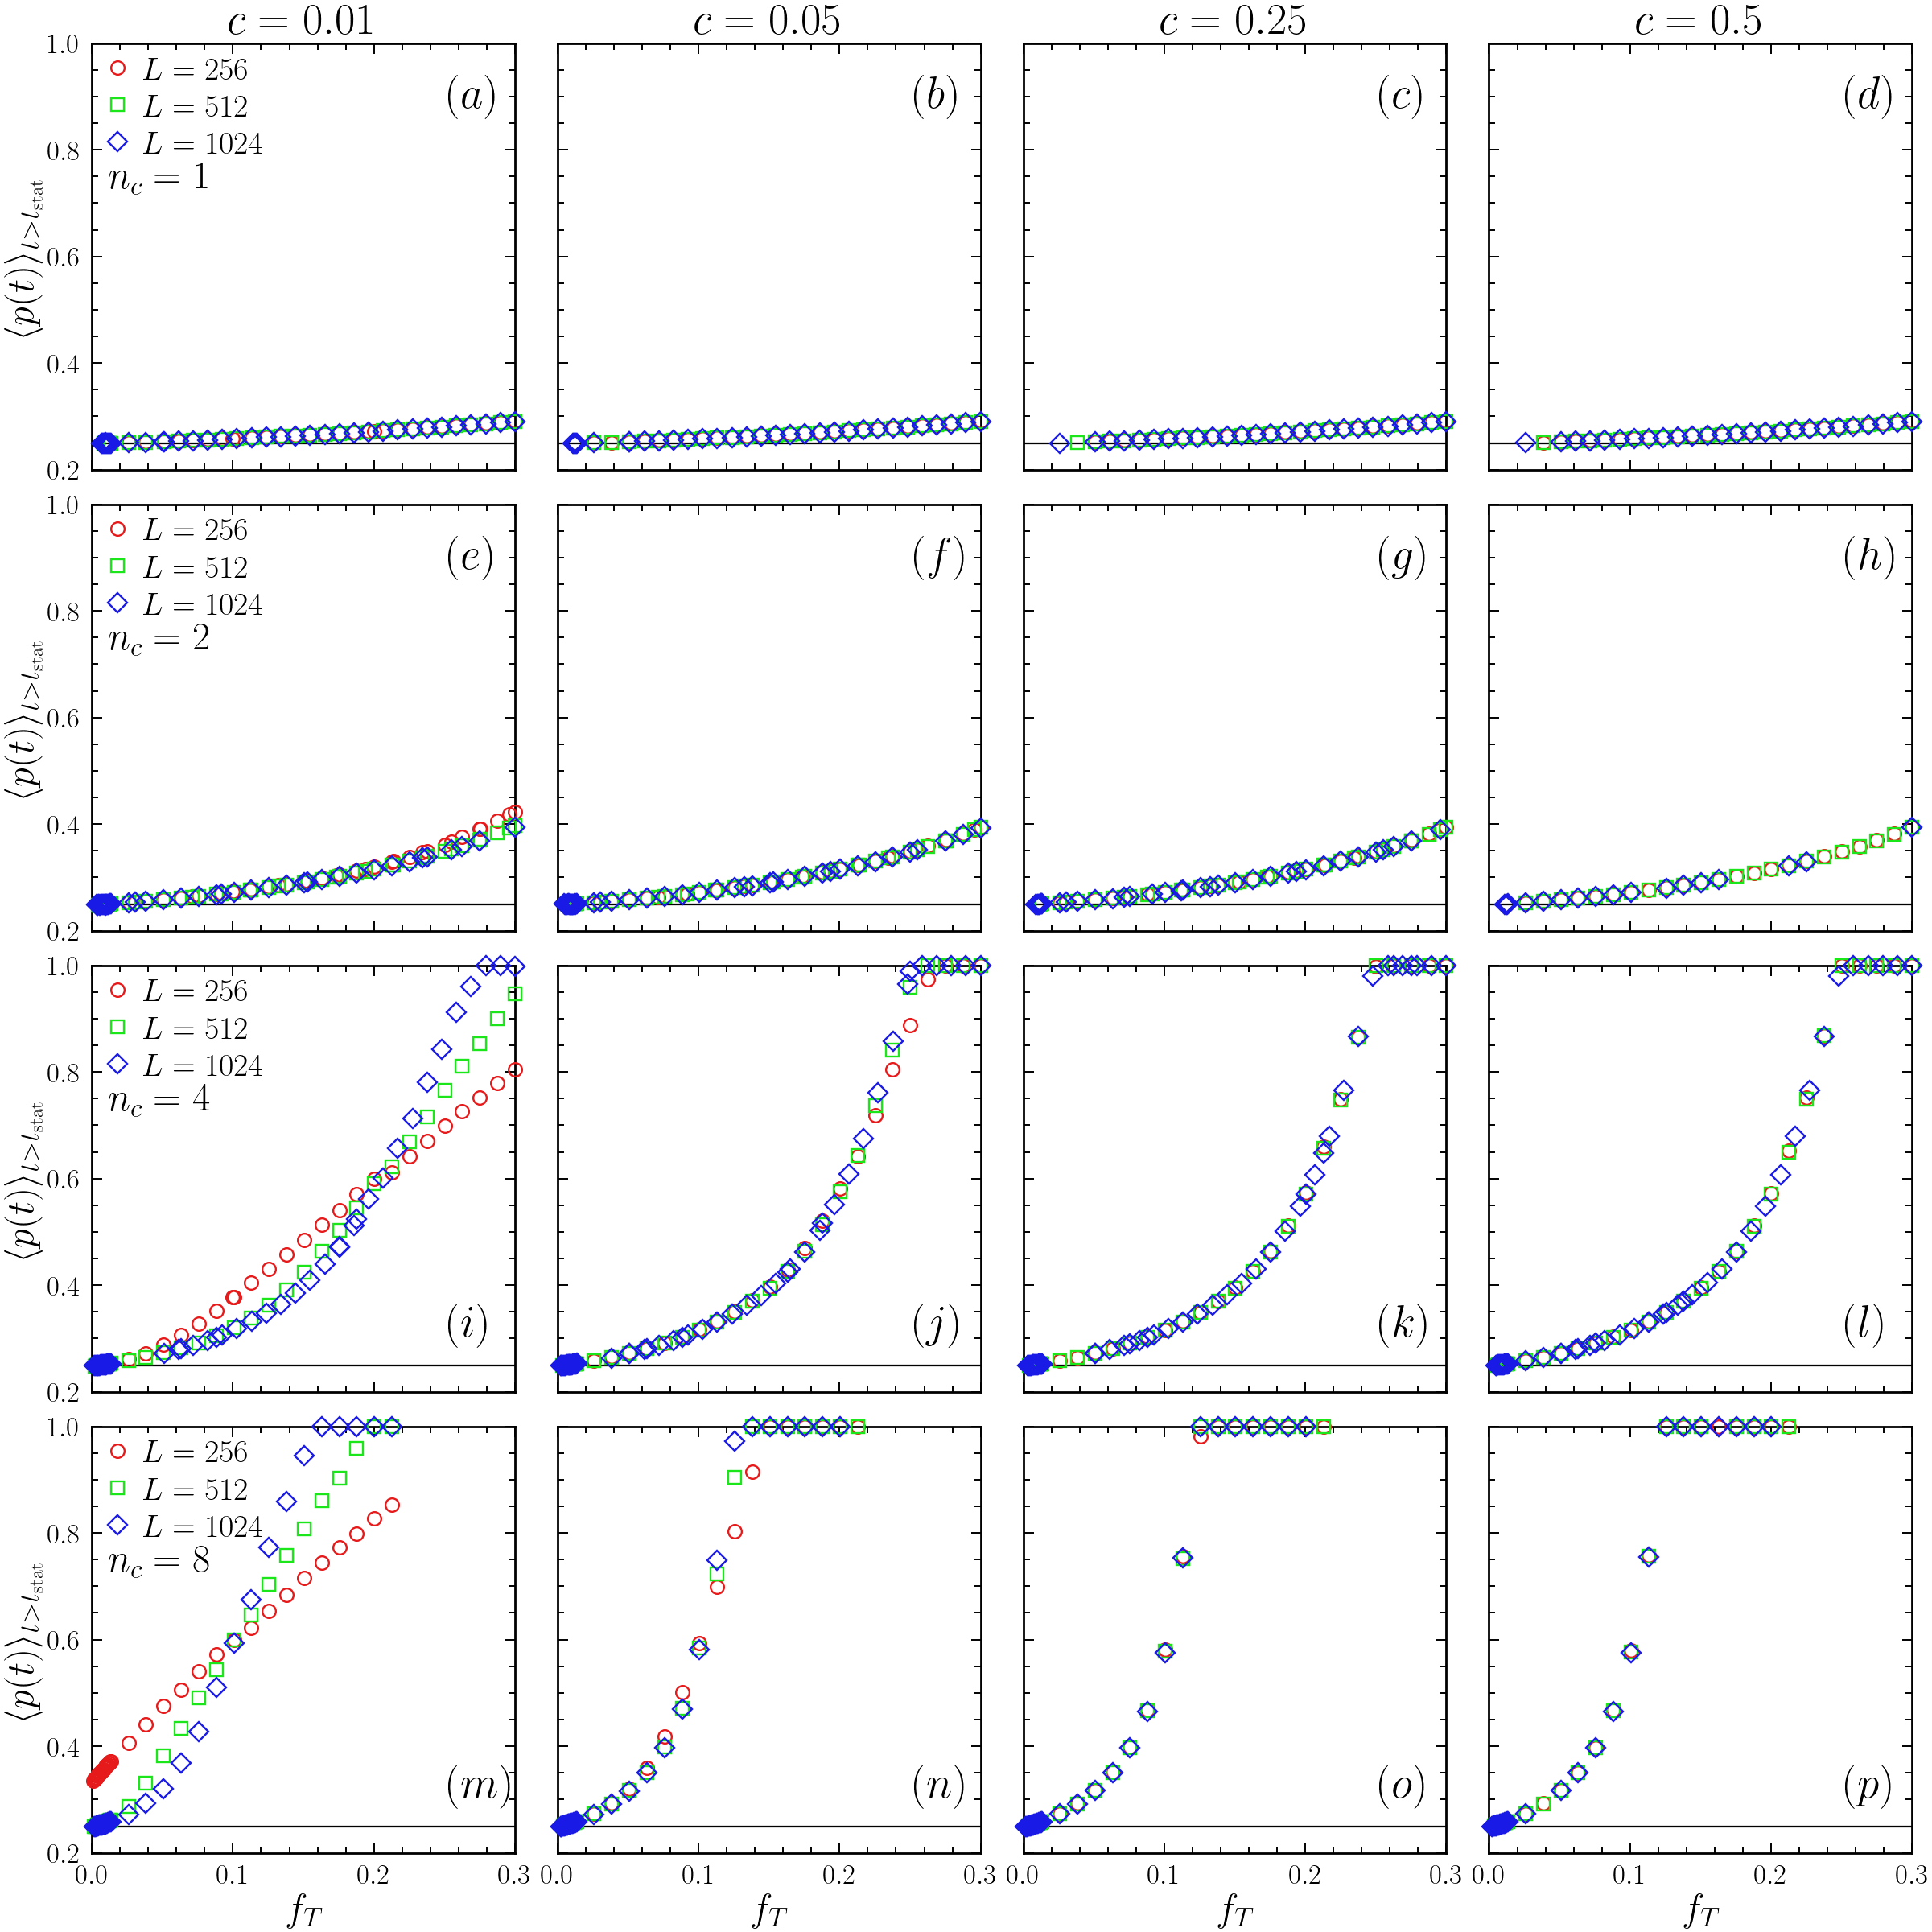

In [11]:
L_lst = [256, 512, 1024]
#L_lst = [256]
c_lst = [0.01, 0.05, 0.25, 0.50]
nc_lst = [1, 2, 4, 8]
p0 = 0.6
P0 = 0.1

base = 6
#fig, axes = plt.subplots(1, len(c_lst), figsize=(4*base, 1*base), constrained_layout=True, sharey=True)
fig, axes = plt.subplots(len(nc_lst), len(c_lst), figsize=(len(c_lst)*base, len(nc_lst)*base), constrained_layout=True, sharey=True, sharex=True)
markers = ['o', 's', 'D']

mew = 1.7
pc = 0.24881182
fs_l_fig = 35
fs_legend = 29
fs_title = 40
tick_size = 20
tick_label_size = 25
labels_size = 35
fs_labels_fig = 40
fs_l_fig = 35
ms = 12
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$',r'$(d)$',
              r'$(e)$', r'$(f)$', r'$(g)$', r'$(h)$',
              r'$(i)$',r'$(j)$', r'$(k)$', r'$(l)$',
              r'$(m)$', r'$(n)$', r'$(o)$', r'$(p)$'
              ]
count = 0
f_TMAX = 0.3
for idx_nc, nc in enumerate(nc_lst):
    ymax = 0
    for idx_c, c in enumerate(c_lst):
        for idx, L in enumerate(L_lst):
            ax = axes[idx_nc, idx_c]
            rho = 1/nc
            df_b = df[(df['nc']==nc) & (df['L']==L) & (df['c']==c) & (df['type_perc']=='bond') & 
                      (df['p0']==p0) & (df['P0']==P0) & (df['order']==1) & (df['rho']==rho)].sort_values('f_T')
            df_b = df_b[df_b['f_T']<=f_TMAX]
            f_t = df_b['f_T']
            pmean = df_b['p_mean']
            ax.plot(f_t, pmean, marker=markers[idx],ms=ms, mew = mew, ls='None', label=f'$L={L}$',zorder=10, clip_on=False)
            ax.axhline(pc, color='k', ls='solid')
            y_max = max(ymax, max(pmean))
        
        if(idx_c==0):
            ax.text(0.04, 0.66, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
            ax.set_ylabel(r'$\langle p(t) \rangle_{t>t_\mathrm{stat}}$', fontsize=labels_size)
            ax.legend(fontsize=fs_legend,loc='upper left', frameon=False)
        if idx_nc==0:
            ax.set_title(f'$c={c}$', fontsize=fs_title)
        if(idx_nc==len(nc_lst)-1):
            ax.set_xlabel(r'$f_T$', fontsize=labels_size)
        ax.set_ylim(0.2, y_max)
        ax.tick_params(axis='both', which='major', labelsize=tick_label_size, pad=10)
        ax.tick_params(axis='both', which='minor', labelsize=tick_label_size, pad=10)
        ax.tick_params(axis='x', which='minor', pad=6)
        ax.tick_params(axis='y', which='minor', pad=6)
        ax.set_xlim(0, 0.3)
for idx, ax in enumerate(axes.flatten()):
    
    if(0 <=idx<= 7):
        ax.text(0.84, 0.85, labels_fig[idx], transform=ax.transAxes , fontsize=fs_labels_fig)
    else:
        ax.text(0.84, 0.13, labels_fig[idx], transform=ax.transAxes , fontsize=fs_labels_fig)

plt.savefig(f"{results}/p_mean_vs_f_T.png", dpi=300)
plt.show()

In [12]:
df_sub = df[
    (df["nc"].isin(nc_lst)) &
    (df["L"].isin(L_lst)) &
    (df["c"].isin(c_lst)) &
    (df["type_perc"] == "bond") &
    (df["p0"] == p0) &
    (df["P0"] == P0)
].copy()

# Evita problemas de comparação entre floats
df_sub["f_T_round"] = df_sub["f_T"].round(12)

# Mantém apenas os f_T que aparecem para todos os L
df_common = (
    df_sub
    .groupby(["nc", "c", "f_T_round"])["L"]
    .nunique()
    .reset_index(name="n_L")
)

df_common = df_common[df_common["n_L"] == len(L_lst)].copy()

# Constrói diretamente o DataFrame final em formato wide
rows = []

for (nc, c_val), g in df_common.groupby(["nc", "c"]):
    vals = np.sort(g["f_T_round"].dropna().unique())

    if len(vals) == 0:
        continue

    f_min = vals[0]
    f_max = vals[-1]

    # ponto médio do intervalo
    f_target = 0.5 * (f_min + f_max)

    # escolhe o f_T disponível mais próximo do ponto médio
    f_mid = vals[np.argmin(np.abs(vals - f_target))]

    rows.append({
        "nc": nc,
        "c": c_val,
        "f_T_min_common": f_min,
        "f_T_mid_common": f_mid,
        "f_T_max_common": f_max,
        "n_f_T_common": len(vals)
    })

df_ft_common = pd.DataFrame(rows)

df_ft_common.to_csv(f"../SOP_data/f_T_common.csv", index=False)


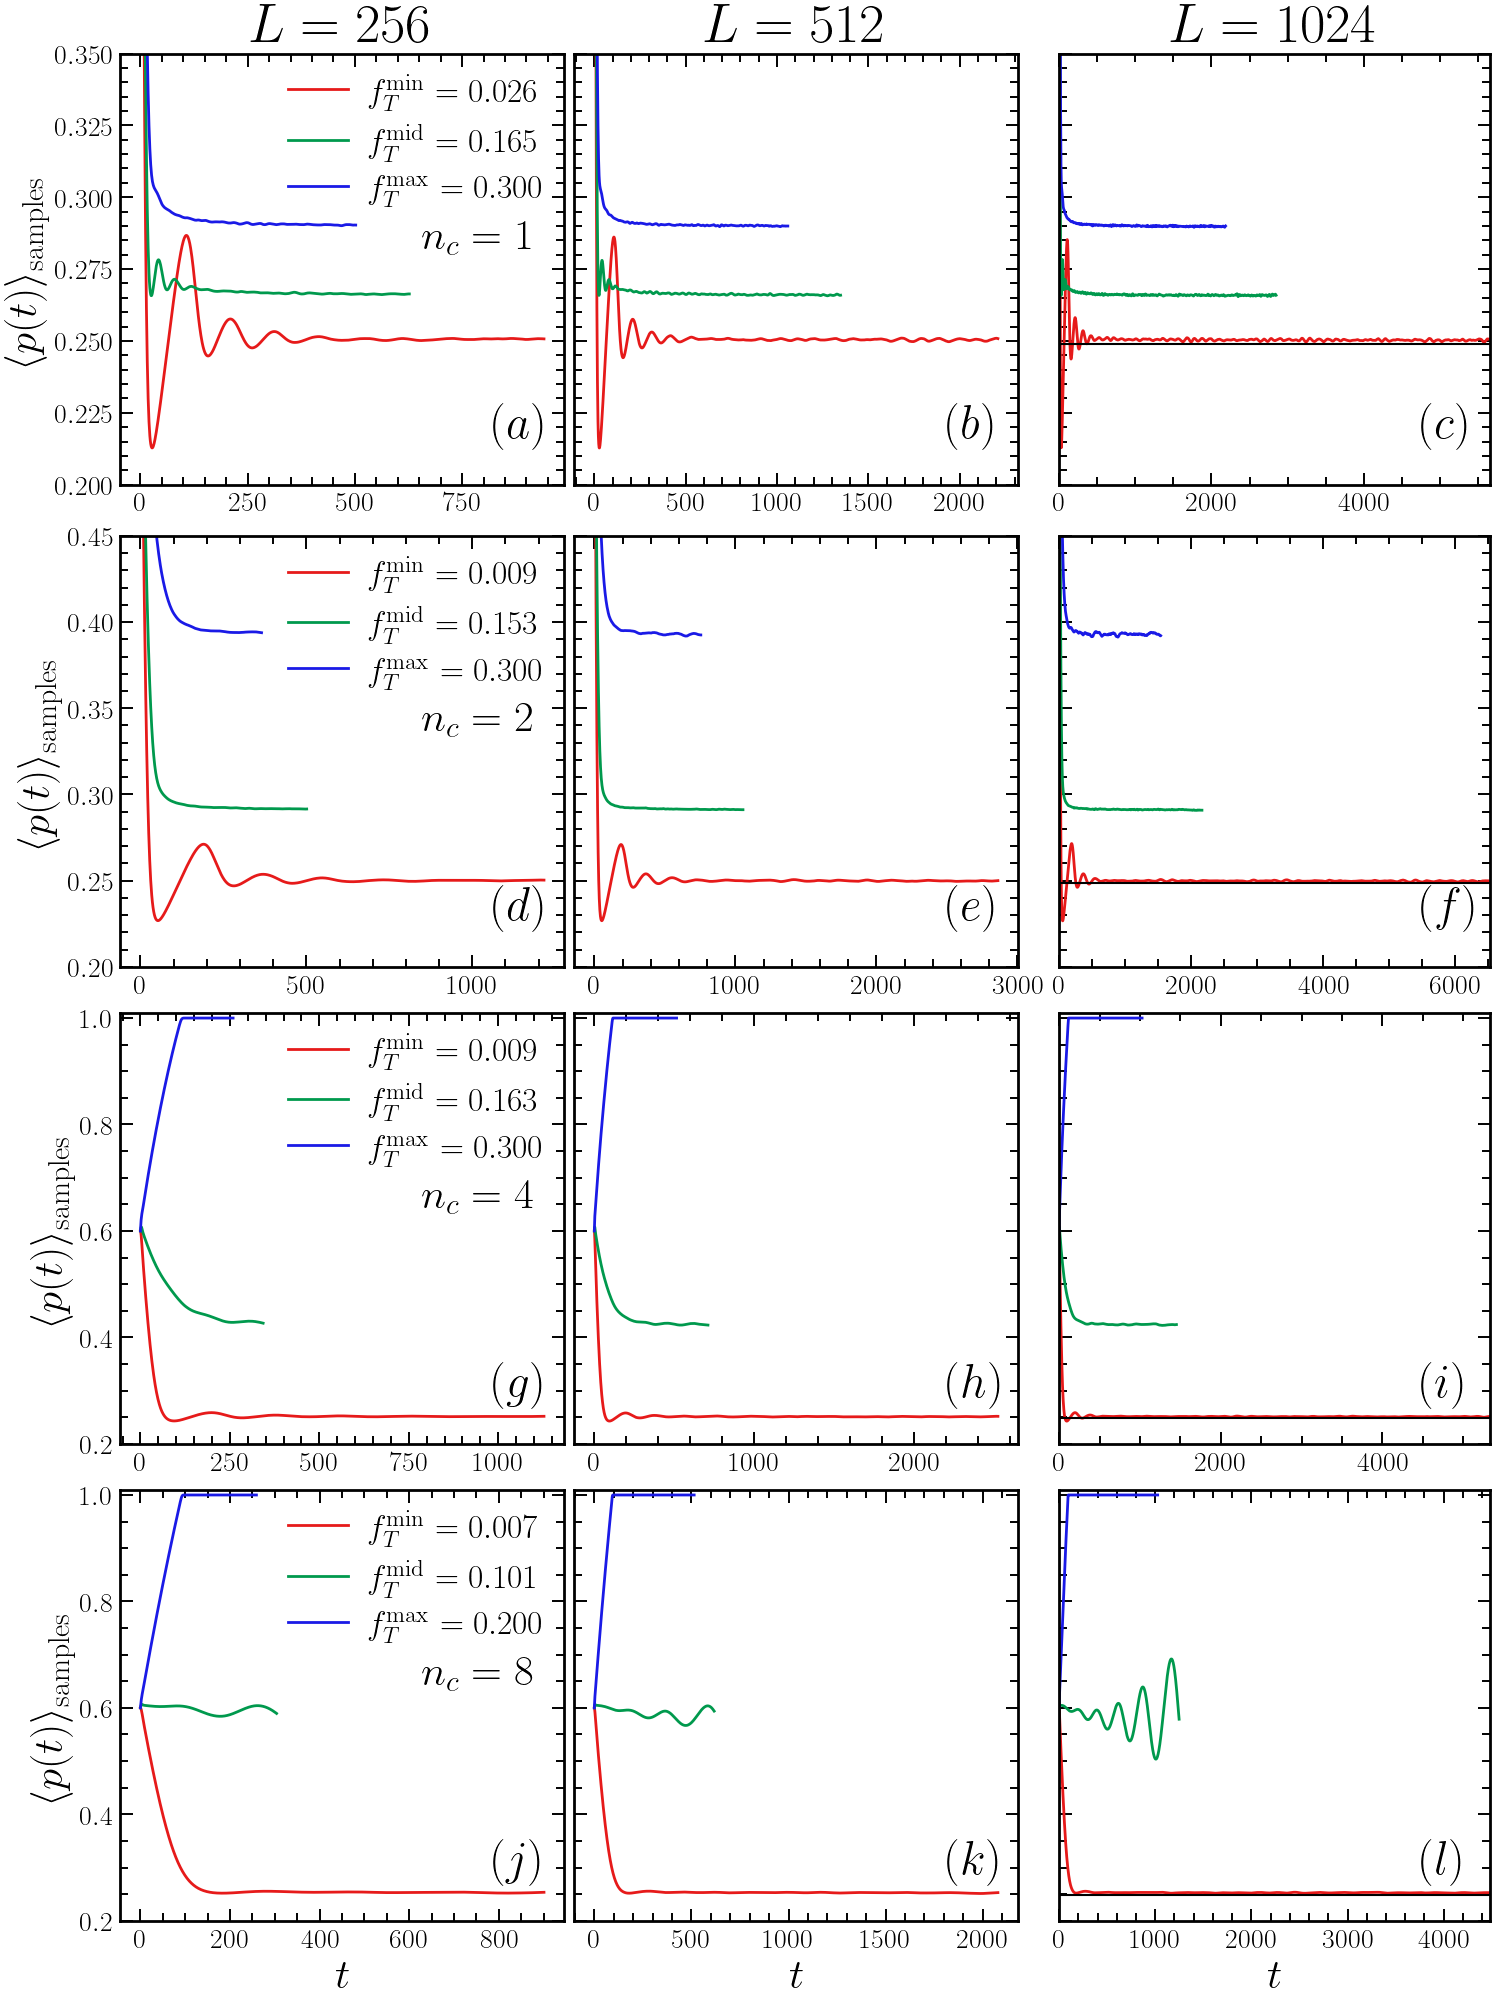

In [33]:
# =========================
# Parâmetros
# =========================
c = 0.05
L_lst = [256, 512, 1024]
dim = 3
nc_lst = [1, 2, 4, 8]

p0 = 0.6
P0 = 0.1
order_mean = 0

pc = 0.24881182

base = 5

fig, axes = plt.subplots(
    len(nc_lst),
    len(L_lst),
    figsize=(3*base, 4*base),
    constrained_layout=True,
    sharey='row',
)

colors = [
    (0.90, 0.10, 0.10),  # red
    (0.00, 0.60, 0.30),  # green
    (0.10, 0.10, 0.90),  # blue
]

ft_cols = [
    "f_T_min_common",
    "f_T_mid_common",
    "f_T_max_common"
]

ft_names = [
    r"$f_T^{\min}$",
    r"$f_T^{\mathrm{mid}}$",
    r"$f_T^{\max}$"
]

labels_fig = [
    r'$(a)$', r'$(b)$', r'$(c)$',
    r'$(d)$', r'$(e)$', r'$(f)$',
    r'$(g)$', r'$(h)$', r'$(i)$',
    r'$(j)$', r'$(k)$', r'$(l)$',
]

fs_labels_fig = 34
fs_l_fig = 31
fs_labels = 31
fs_legend = 24
fs_title = 40

parms_need = []
lw = 2.0
# =========================
# Plot
# =========================

for idx_nc, nc in enumerate(nc_lst):
    t_max = 0
    y_max = 0
    # Pega os f_T comum para este par (nc, c)
    row_ft = df_ft_common[
        (df_ft_common["nc"] == nc) &
        ((np.isclose(df_ft_common["c"], c)))
    ]

    if row_ft.empty:
        print(f"Nenhum f_T comum encontrado para nc = {nc}, c = {c}")
        continue

    row_ft = row_ft.iloc[0]

    fT_values = []
    fT_labels = []

    for col, name in zip(ft_cols, ft_names):
        fT = row_ft[col]

        if np.isfinite(fT):
            fT_values.append(float(fT))
            fT_labels.append(name)

    # Remove valores repetidos, caso f_T_min = f_T_mid ou f_T_mid = f_T_max
    unique_pairs = []
    for fT, label in zip(fT_values, fT_labels):
        if not any(np.isclose(fT, old_fT) for old_fT, _ in unique_pairs):
            unique_pairs.append((fT, label))

    for idx_L, L in enumerate(L_lst):

        ax = axes[idx_nc, idx_L]
        rho = 1 / nc

        for idx_fT, (fT, fT_label) in enumerate(unique_pairs):

            path = (
                f"../SOP_data/published/bond_percolation/"
                f"num_colors_{nc}/dim_{dim}/L_{L}/"
                f"fT_constant/fT_{fT:.6e}/"
                f"c_{c:.6e}/rho_{rho:.4e}"
            )

            fn = path + "/properties_mean_bundle.json"

            try:
                bundle = load_properties_bundle(fn)

                try:
                    data = bundle[p0]["orders"][order_mean]

                except KeyError:
                    print(f"KeyError: nc={nc}, L={L}, c={c}, fT={fT}, p0={p0}")
                    parms_need.append((nc, L, c, fT, p0))
                    continue

                time = data["time"]
                pt_mean = data["pt_mean"]

                ax.plot(
                    time,
                    pt_mean,
                    ls='solid',
                    lw =lw,
                    color=colors[idx_fT],
                    label=fr"{fT_label} $= {fT:.3f}$"
                )

                t_max = max(t_max, max(time))
                y_max = max(y_max, max(pt_mean))
            except FileNotFoundError:
                print(f"File not found: {fn}")
                parms_need.append((nc, L, c, fT, p0))
                continue
    

        if idx_L == 0:
            ax.text(
                0.68,
                0.55,
                fr"$n_c = {nc}$",
                transform=ax.transAxes,
                fontsize=fs_l_fig
            )

            leg = ax.legend(
                fontsize=fs_legend,
                handlelength=1.8,
                handletextpad=0.6,
                borderpad=0.4,
                labelspacing=0.4
            )

            for line in leg.get_lines():
                line.set_linewidth(2.0)

        if idx_nc == 0:
            ax.set_title(fr"$L = {L}$", fontsize=fs_title)

        # Mesma lógica de escala em y do seu código original
        # if idx_nc == 0 or idx_nc == 1:
        #     ax.set_ylim(0.2, 0.3)
        # elif idx_nc == 2:
        #     ax.set_ylim(0.2, 0.35)
        # elif idx_nc == 3:
        #     ax.set_ylim(0.2, 0.8)
    ax.set_xlim(0, t_max)
    ax.set_ylim(0.2, y_max)
    ax.axhline(pc, color='k', ls='solid')
    ax.set_box_aspect(1)
y_min = 0.2
for i, row in enumerate(axes):
    for ax in row:
        if i == 0:
            ax.set_ylim(y_min, 0.35)
        elif i == 1:
            ax.set_ylim(y_min, 0.45)
        elif i == 2:
            ax.set_ylim(y_min, 1.01)
        elif i == 3:
            ax.set_ylim(y_min, 1.01)
# =========================
# Ajustes finais
# =========================
for idx, ax in enumerate(axes.flatten()):
    
    ax.text(
        0.84,
        0.11,
        labels_fig[idx],
        transform=ax.transAxes,
        fontsize=fs_labels_fig
    )

for ax in axes[:, 0]:
    ax.set_ylabel(r'$\langle p(t) \rangle_{\mathrm{samples}}$',fontsize=fs_labels)

for ax in axes[-1, :]:
    ax.set_xlabel(r'$t$',fontsize=fs_labels)
plt.savefig(f"{results}/p_samples_vs_f_T.png", dpi=300)
plt.show()

## Height Effects ($z=L$, $z=2L$, $z=3L$)

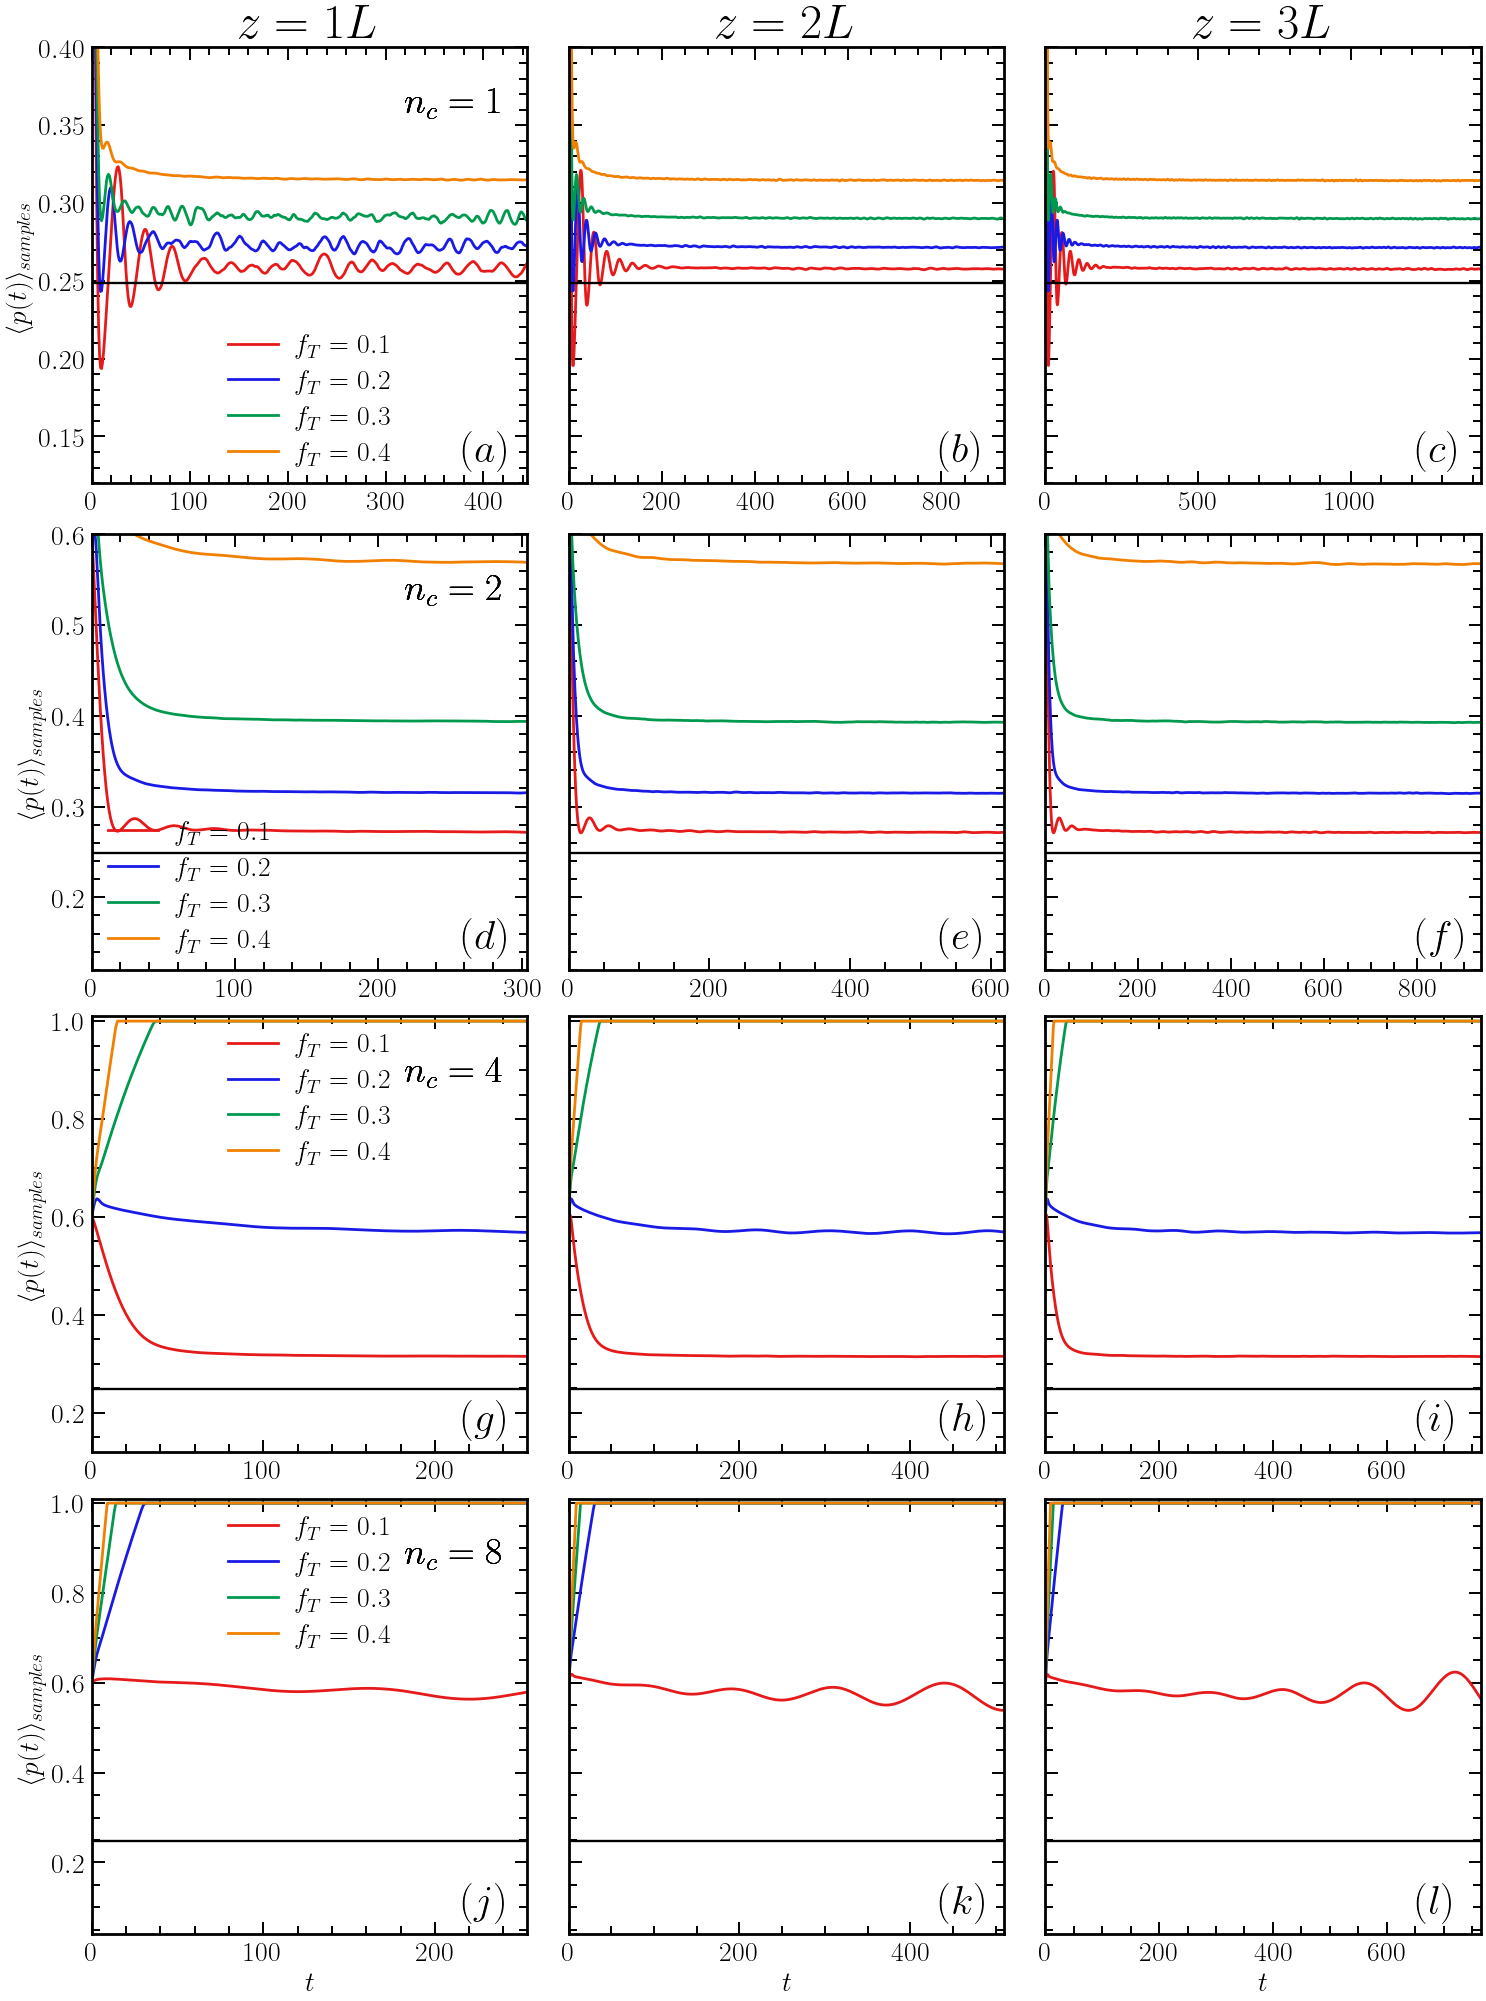

In [54]:
fT_lst = [0.1, 0.2, 0.3, 0.4]
c = 0.15
L = 256
dim = 3
nc_lst = [1, 2, 4, 8]
p0 = 0.6
base = 5
#p0_values = [0.3, 0.7, 1.0]
fig, axes = plt.subplots(len(nc_lst), 3, figsize=(3*base, 4*base), constrained_layout=True,sharey='row')
order_mean = 0
pc = 0.24881182
colors = [
    (0.90, 0.10, 0.10),  # red
    (0.10, 0.10, 0.90),  # blue
    (0.00, 0.60, 0.30),  # green
    (0.95, 0.50, 0.00),  # orange
    (0.65, 0.20, 0.75),  # purple
    (0.00, 0.70, 0.70),  # teal
    (0.55, 0.55, 0.00),  # olive
    (0.45, 0.25, 0.10),  # brown
]
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$',
              r'$(d)$', r'$(e)$', r'$(f)$',
              r'$(g)$', r'$(h)$', r'$(i)$',
              r'$(j)$', r'$(k)$', r'$(l)$',]

fs_labels_fig = 30
fs_l_fig = 27
fs_title = 35
fs_legend = 20
t_max = 0
parms_list = []
lw = 2.0
for idx_nc, nc in enumerate(nc_lst):
    
    for index in range(3):
        ax = axes[idx_nc, index]
        
        for idx_ft, ft in enumerate(fT_lst):
        
            rho = 1/nc
            if(index == 0):
                path = f"../SOP_data/published/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/fT_constant/fT_{ft:.6e}/c_{c:.6e}/rho_{rho:.4e}"
            elif(index == 1):
                path = f"../SOP_data/published_2L_stop/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/fT_constant/fT_{ft:.6e}/c_{c:.6e}/rho_{rho:.4e}"
            elif(index == 2):
                path = f"../SOP_data/published_3L_stop/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/fT_constant/fT_{ft:.6e}/c_{c:.6e}/rho_{rho:.4e}"
            
            fn = path + "/properties_mean_bundle.json"
            try:
                bundle = load_properties_bundle(fn)
                data = bundle[p0]["orders"][order_mean]
                time = data["time"]
                pt_mean = data["pt_mean"]
                t_max = max(time)
                
                ax.plot(time, pt_mean, ls='solid',lw=lw, color=colors[idx_ft], label=f'$f_T = {ft}$')
                ax.set_xlim(0, t_max)
            except KeyError:
                print(f"File not found: {fn}")
                parms_list.append((nc, ft, p0, path))
                continue
            except FileNotFoundError:
                print(f"File not found: {fn}")
                parms_list.append((nc, ft, p0, path))
                continue
            
            
                
            ax.axhline(pc, color='k', ls='solid')
            #ax.set_ylim(0.245, 0.265)
            ax.set_box_aspect(1)
            if idx_nc == 0:
                ax.set_title(f'$z = {index+1}L$', fontsize=fs_title)
                ax.set_ylim(0.2, 0.4)
            if idx_nc == 1:
                ax.set_ylim(0.2, 0.6)
            if idx_nc == 2 and idx_nc==3:
                ax.set_ylim(0.2, 1.0)
            if index==0:
                leg = ax.legend(
                    fontsize=fs_legend,
                    handlelength=1.8,
                    handletextpad=0.6,
                    borderpad=0.4,
                    labelspacing=0.4
                )

                for line in leg.get_lines():
                    line.set_linewidth(2.0)
                
                ax.set_ylabel(r'$\langle p(t) \rangle_{samples}$')
                ax.text(0.72, 0.85, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
            if idx_nc == len(nc_lst)-1:
                ax.set_xlabel(r'$t$')
            if index != 0:
                ax.tick_params(axis='y', labelleft=False)
y_min = 0.12
for i, row in enumerate(axes):
    for ax in row:
        if i == 0:
            ax.set_ylim(y_min, 0.40)
        elif i == 1:
            ax.set_ylim(y_min, 0.60)
        elif i == 2:
            ax.set_ylim(y_min, 1.01)
        elif i == 3:
            ax.set_ylim(y_min-0.08, 1.01)
for idx, ax in enumerate(axes.flatten()):
    
    ax.text(0.85, 0.05, labels_fig[idx], transform=ax.transAxes , fontsize=fs_labels_fig)
plt.savefig(f"{results}/height_effects.png", dpi=300)
plt.show()

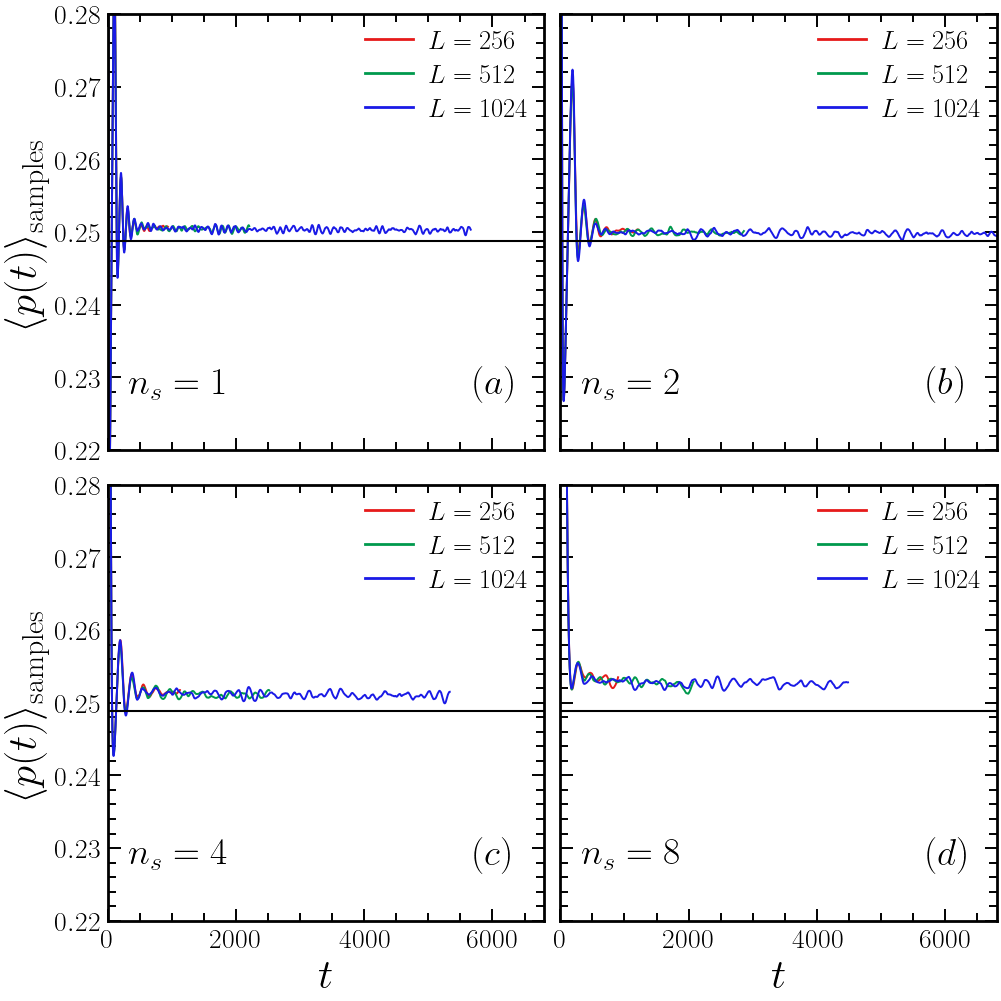

In [8]:
nc_lst = [1,2,4,8]
L_lst = [256, 512, 1024]
c = 0.05
dim = 3
p0 = 0.6
base = 10
fig, axes = plt.subplots(2, 2, figsize=(base, base), sharex=True, sharey=True, constrained_layout=True)

fs_legend = 19
fs_labels_fig = 27
t_max = 0
colors = [
    (0.90, 0.10, 0.10),  # red
    (0.00, 0.60, 0.30),  # green
    (0.10, 0.10, 0.90),  # blue
]
labels_fig = [
    r'$(a)$', r'$(b)$', r'$(c)$', r'$(d)$']

pc = 0.24881182
for idx, ax in enumerate(axes.flatten()):
    fT = df_ft_common[(df_ft_common["nc"] == nc_lst[idx]) & (df_ft_common["c"] == c)]["f_T_min_common"].values[0]
    rho = 1/nc_lst[idx]
    for idx_L,L in enumerate(L_lst):
        path = (
            f"../SOP_data/published/bond_percolation/"
            f"num_colors_{nc_lst[idx]}/dim_{dim}/L_{L}/"
            f"fT_constant/fT_{fT:.6e}/"
            f"c_{c:.6e}/rho_{rho:.4e}"
        )

        fn = path + "/properties_mean_bundle.json"

        try:
            bundle = load_properties_bundle(fn)

            try:
                data = bundle[p0]["orders"][order_mean]

            except KeyError:
                print(f"KeyError: nc={nc}, L={L}, c={c}, fT={fT}, p0={p0}")
                parms_need.append((nc, L, c, fT, p0))
                continue
            
            time = data["time"]
            pt_mean = data["pt_mean"]
            t_max = max(t_max, max(time))
            ax.plot(
                time,
                pt_mean,
                ls='solid',
                lw = 1.4,
                color=colors[idx_L],
                label=fr"$L = {L}$"
            )
        except FileNotFoundError:
            print(f"File not found: {fn}")
            continue
    if(idx==0  or idx==2):
        ax.set_ylabel(r'$\langle p(t) \rangle_{\mathrm{samples}}$',fontsize=fs_labels)
    if(idx==2 or idx==3):
        ax.set_xlabel(r'$t$',fontsize=fs_labels)
for idx, ax in enumerate(axes.flatten()):
    ax.set_ylim(0.22, 0.28)
    ax.set_xlim(0, t_max)
    ax.text(
        0.84,
        0.13,
        labels_fig[idx],
        transform=ax.transAxes,
        fontsize=fs_labels_fig
    )

    ax.text(
        0.05,
        0.13,
        f"$n_s = {nc_lst[idx]}$",
        transform=ax.transAxes,
        fontsize=fs_labels_fig
    )
    leg = ax.legend(
        fontsize=fs_legend,
        handlelength=1.8,
        handletextpad=0.6,
        borderpad=0.4,
        labelspacing=0.4
    )

    for line in leg.get_lines():
        line.set_linewidth(2.0)
    ax.axhline(pc, color='k', ls='solid')
plt.savefig(f"{results}/p_samples_fT_min.png", dpi=300)
plt.show()

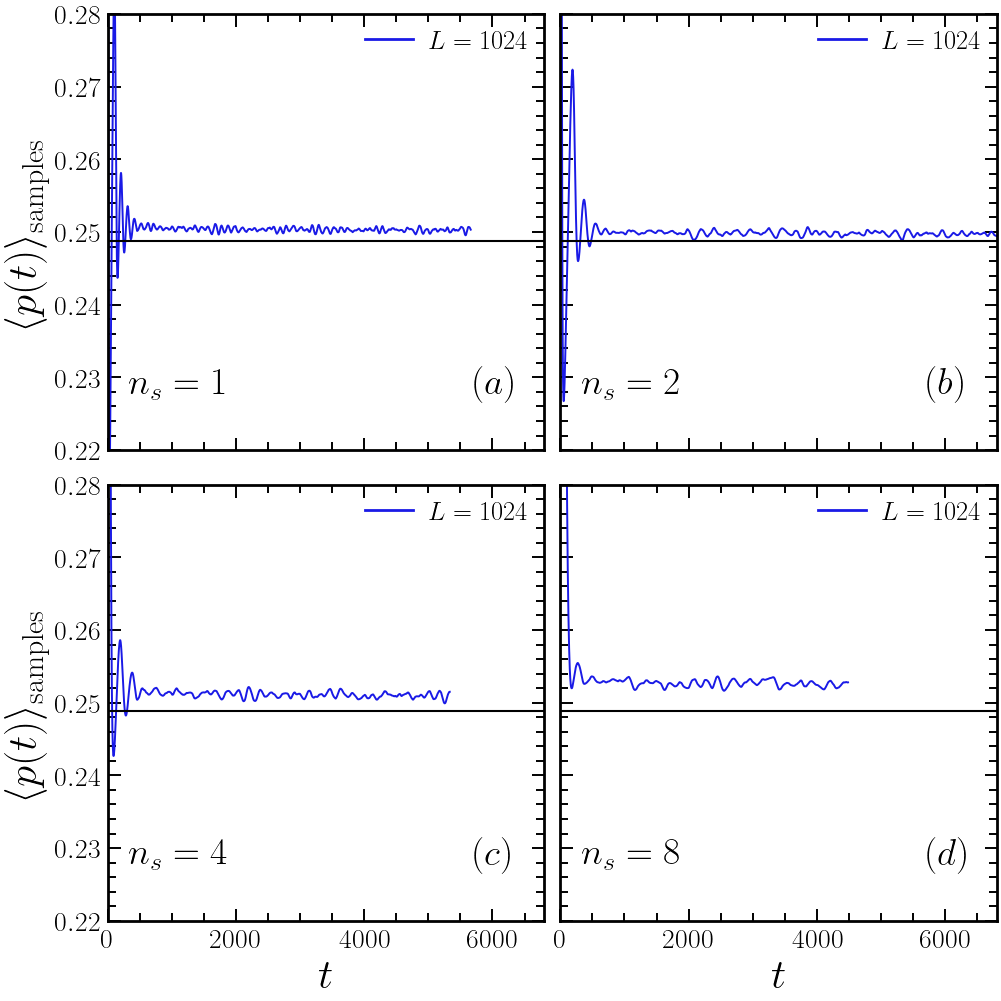

In [131]:
nc_lst = [1,2,4,8]
L = 1024
c = 0.05
dim = 3
p0 = 0.6
base = 10
fig, axes = plt.subplots(2, 2, figsize=(base, base), sharex=True, sharey=True, constrained_layout=True)

fs_legend = 19
fs_labels_fig = 27
t_max = 0
colors = [
    (0.90, 0.10, 0.10),  # red
    (0.00, 0.60, 0.30),  # green
    (0.10, 0.10, 0.90),  # blue
]
labels_fig = [
    r'$(a)$', r'$(b)$', r'$(c)$', r'$(d)$']

pc = 0.24881182
for idx, ax in enumerate(axes.flatten()):
    fT = df_ft_common[(df_ft_common["nc"] == nc_lst[idx]) & (df_ft_common["c"] == c)]["f_T_min_common"].values[0]
    rho = 1/nc_lst[idx]
    
    path = (
        f"../SOP_data/published/bond_percolation/"
        f"num_colors_{nc_lst[idx]}/dim_{dim}/L_{L}/"
        f"fT_constant/fT_{fT:.6e}/"
        f"c_{c:.6e}/rho_{rho:.4e}"
    )

    fn = path + "/properties_mean_bundle.json"

    try:
        bundle = load_properties_bundle(fn)

        try:
            data = bundle[p0]["orders"][order_mean]

        except KeyError:
            print(f"KeyError: nc={nc}, L={L}, c={c}, fT={fT}, p0={p0}")
            parms_need.append((nc, L, c, fT, p0))
            continue
        
        time = data["time"]
        pt_mean = data["pt_mean"]
        t_max = max(t_max, max(time))
        ax.plot(
            time,
            pt_mean,
            ls='solid',
            lw = 1.4,
            color=colors[idx_L],
            label=fr"$L = {L}$"
        )
    except FileNotFoundError:
        print(f"File not found: {fn}")
        continue
    
    if(idx==0  or idx==2):
        ax.set_ylabel(r'$\langle p(t) \rangle_{\mathrm{samples}}$',fontsize=fs_labels)
    if(idx==2 or idx==3):
        ax.set_xlabel(r'$t$',fontsize=fs_labels)
for idx, ax in enumerate(axes.flatten()):
    ax.set_ylim(0.22, 0.28)
    ax.set_xlim(0, t_max)
    ax.text(
        0.84,
        0.13,
        labels_fig[idx],
        transform=ax.transAxes,
        fontsize=fs_labels_fig
    )

    ax.text(
        0.05,
        0.13,
        f"$n_s = {nc_lst[idx]}$",
        transform=ax.transAxes,
        fontsize=fs_labels_fig
    )
    leg = ax.legend(
        fontsize=fs_legend,
        handlelength=1.8,
        handletextpad=0.6,
        borderpad=0.4,
        labelspacing=0.4
    )

    for line in leg.get_lines():
        line.set_linewidth(2.0)
    ax.axhline(pc, color='k', ls='solid')
#plt.savefig(f"{results}/p_samples_fT_min_L{L}.png", dpi=300)
plt.show()

## p(t) SERIES - $p_0$ effects for differents sizes

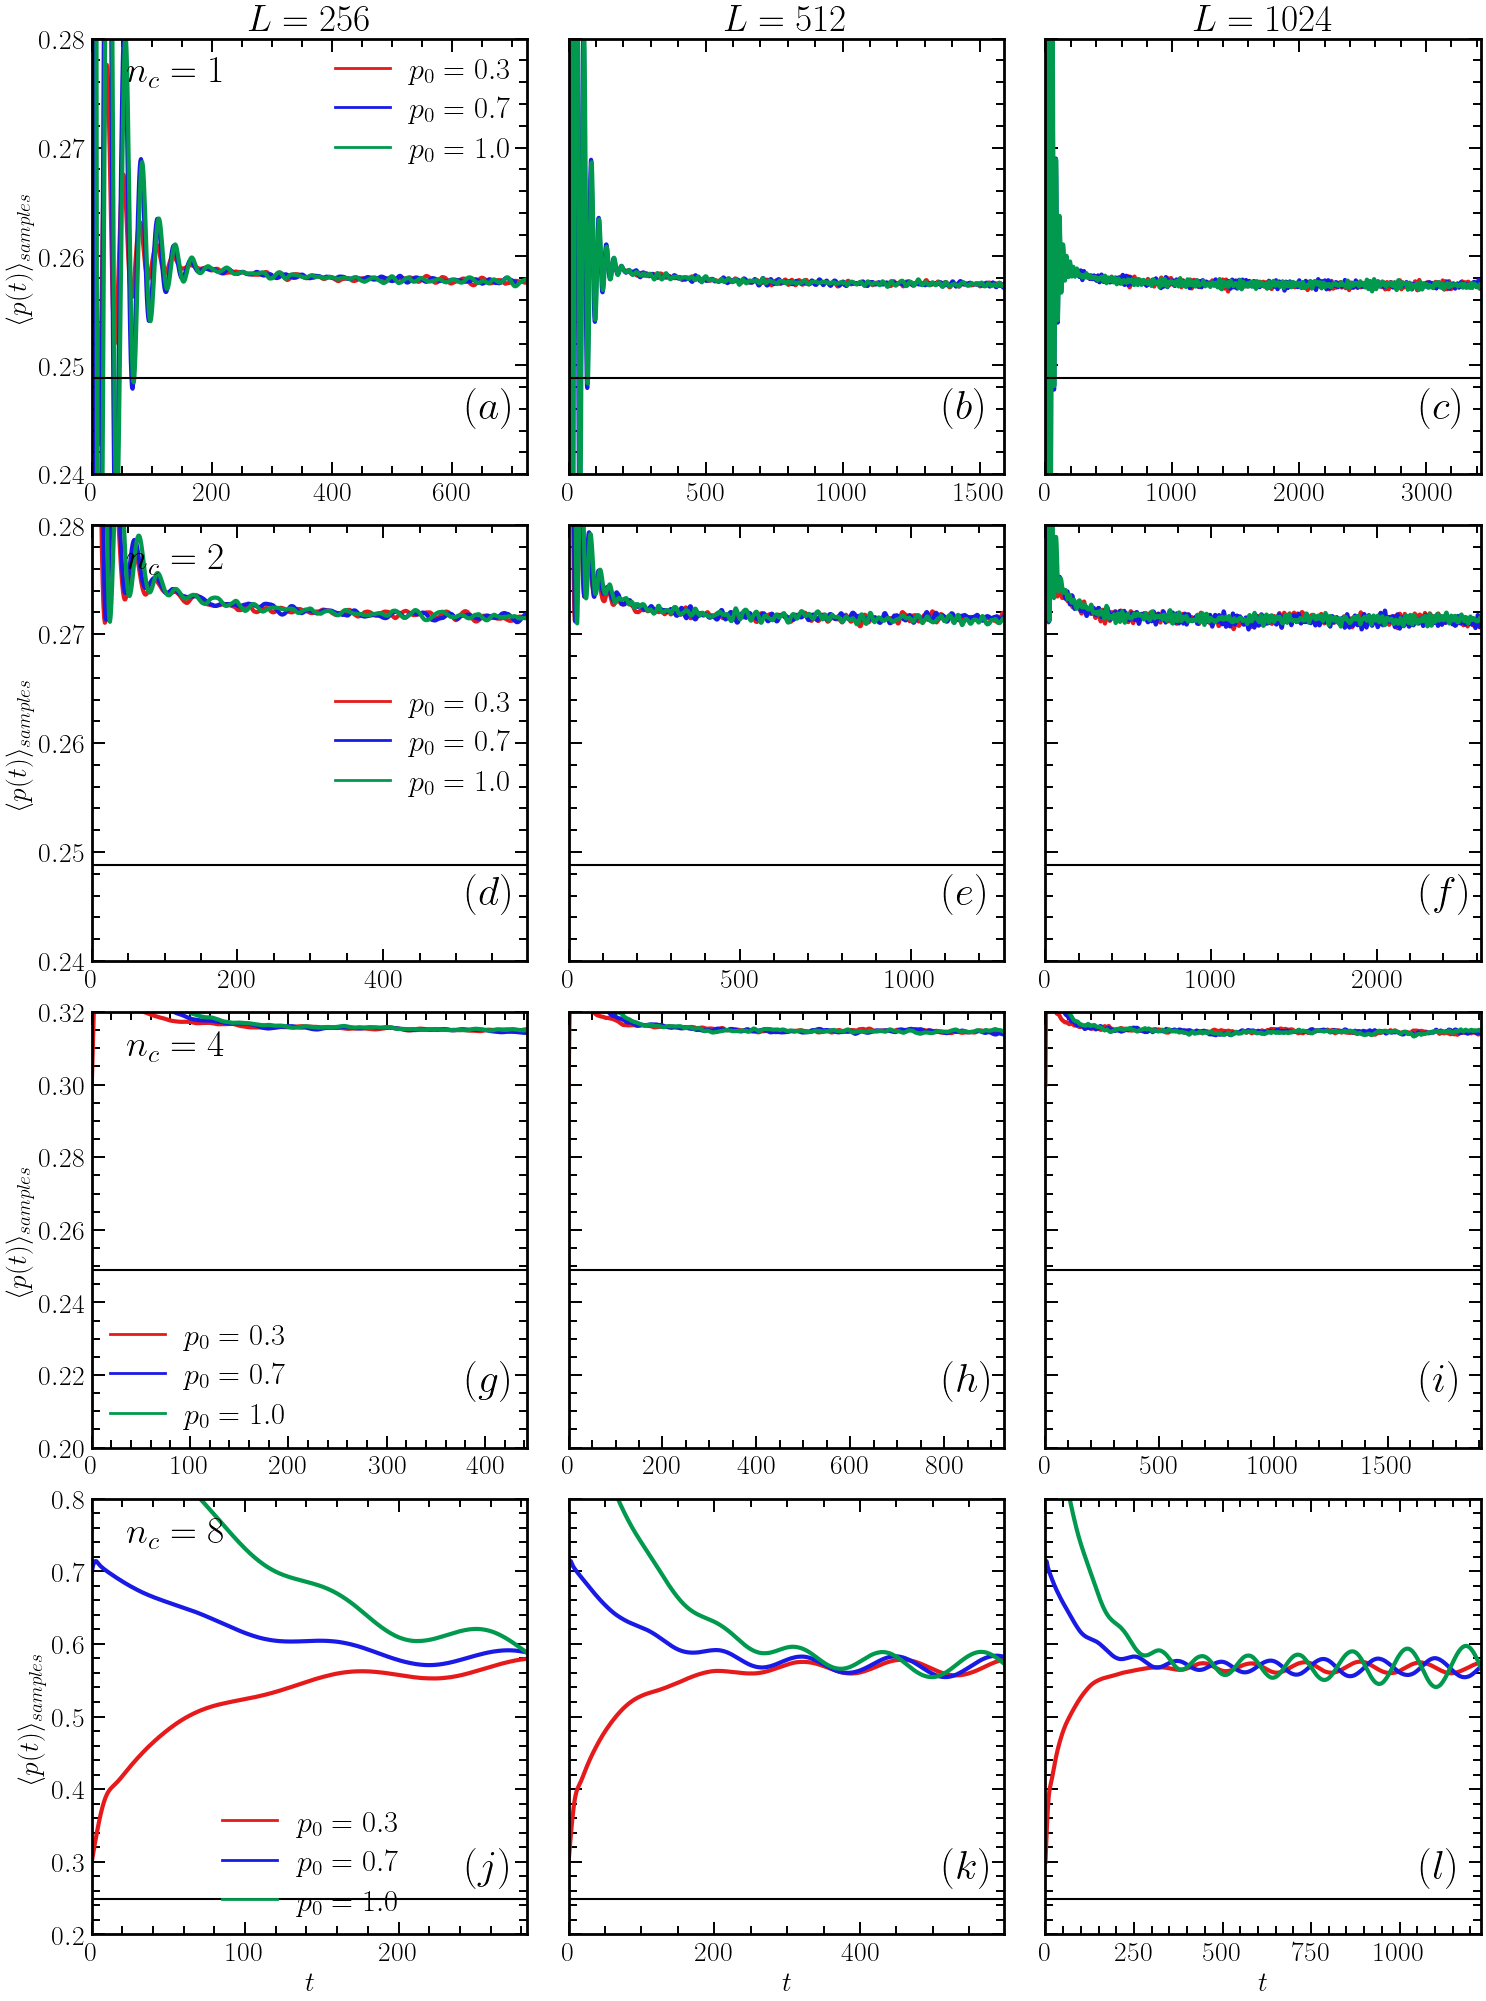

In [58]:
#fT = 0.05
#c = 0.01
fT = 0.1
c=0.15
L_lst = [256, 512, 1024]
dim = 3
nc_lst = [1, 2, 4, 8]

base = 5
p0_values = [0.3, 0.7, 1.0]
fig, axes = plt.subplots(len(nc_lst), len(L_lst), figsize=(3*base, 4*base), constrained_layout=True, sharey='row')
order_mean = 0
pc = 0.24881182
lw = 2.0
colors = [
    (0.90, 0.10, 0.10),  # red
    (0.10, 0.10, 0.90),  # blue
    (0.00, 0.60, 0.30),  # green
    (0.95, 0.50, 0.00),  # orange
    (0.65, 0.20, 0.75),  # purple
    (0.00, 0.70, 0.70),  # teal
    (0.55, 0.55, 0.00),  # olive
    (0.45, 0.25, 0.10),  # brown
]
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$',
              r'$(d)$', r'$(e)$', r'$(f)$',
              r'$(g)$', r'$(h)$', r'$(i)$',
              r'$(j)$', r'$(k)$', r'$(l)$',]

fs_labels_fig = 30
fs_l_fig = 27
lw = 3.0
t_max = 0
parms_need = []
for idx_nc, nc in enumerate(nc_lst):
    for idx_L, L in enumerate(L_lst):
        ax = axes[idx_nc, idx_L]
        rho = 1/nc
        path = f"../SOP_data/published/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/fT_constant/fT_{fT:.6e}/c_{c:.6e}/rho_{rho:.4e}"
        fn = path + "/properties_mean_bundle.json"
        try:
            bundle = load_properties_bundle(fn)
            for idx_p0, p0 in enumerate(p0_values):
                try:
                    data = bundle[p0]["orders"][order_mean]
                
                except KeyError:
                    print(f"KeyError for p0 = {p0}")
                    parms_need.append((nc, L, p0))
                    continue
                time = data["time"]
                pt_mean = data["pt_mean"]
                ax.plot(time, pt_mean, ls='solid',lw=lw, color=colors[idx_p0], label=f'$p_0 = {p0}$')
                t_max = max(time)
                ax.set_xlim(0, t_max)

        except FileNotFoundError:
            print(f"File not found: {fn}")
            parms_need.append((nc, L, p0))
            continue
        ax.axhline(pc, color='k', ls='solid')
        ax.set_ylim(0.2, 0.8)
        ax.set_box_aspect(1)        
        
        if idx_L == 0:
            ax.text(0.08, 0.9, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
            leg = ax.legend(
                fontsize=22,
                handlelength=1.8,
                handletextpad=0.6,
                borderpad=0.4,
                labelspacing=0.4
            )

            for line in leg.get_lines():
                line.set_linewidth(2.0)
        if idx_nc == 0:
            ax.set_title(f'$L = {L}$', fontsize=fs_l_fig)
        if idx_nc ==0:
            ax.set_ylim(0.24, 0.28)
        if idx_nc == 1:
            ax.set_ylim(0.24, 0.28)
        elif idx_nc == 2:
            ax.set_ylim(0.2, 0.32)
        elif idx_nc == 3:
            ax.set_ylim(0.2, 0.8)
        
for idx, ax in enumerate(axes.flatten()):
    
    ax.text(0.86, 0.13, labels_fig[idx], transform=ax.transAxes , fontsize=fs_labels_fig)

for ax in axes[:,0]:
    ax.set_ylabel(r'$\langle p(t) \rangle_{samples}$')
for ax in axes[-1,:]:
    ax.set_xlabel(r'$t$')

#fig.suptitle(f"dim $= {dim}$, $f_T = {fT}$, $n_s = 1$, $c = {c}$", fontsize=30)
plt.savefig(results + f"/p0_effects_multiply_L.png")
plt.show()


## Order Percolation Effects

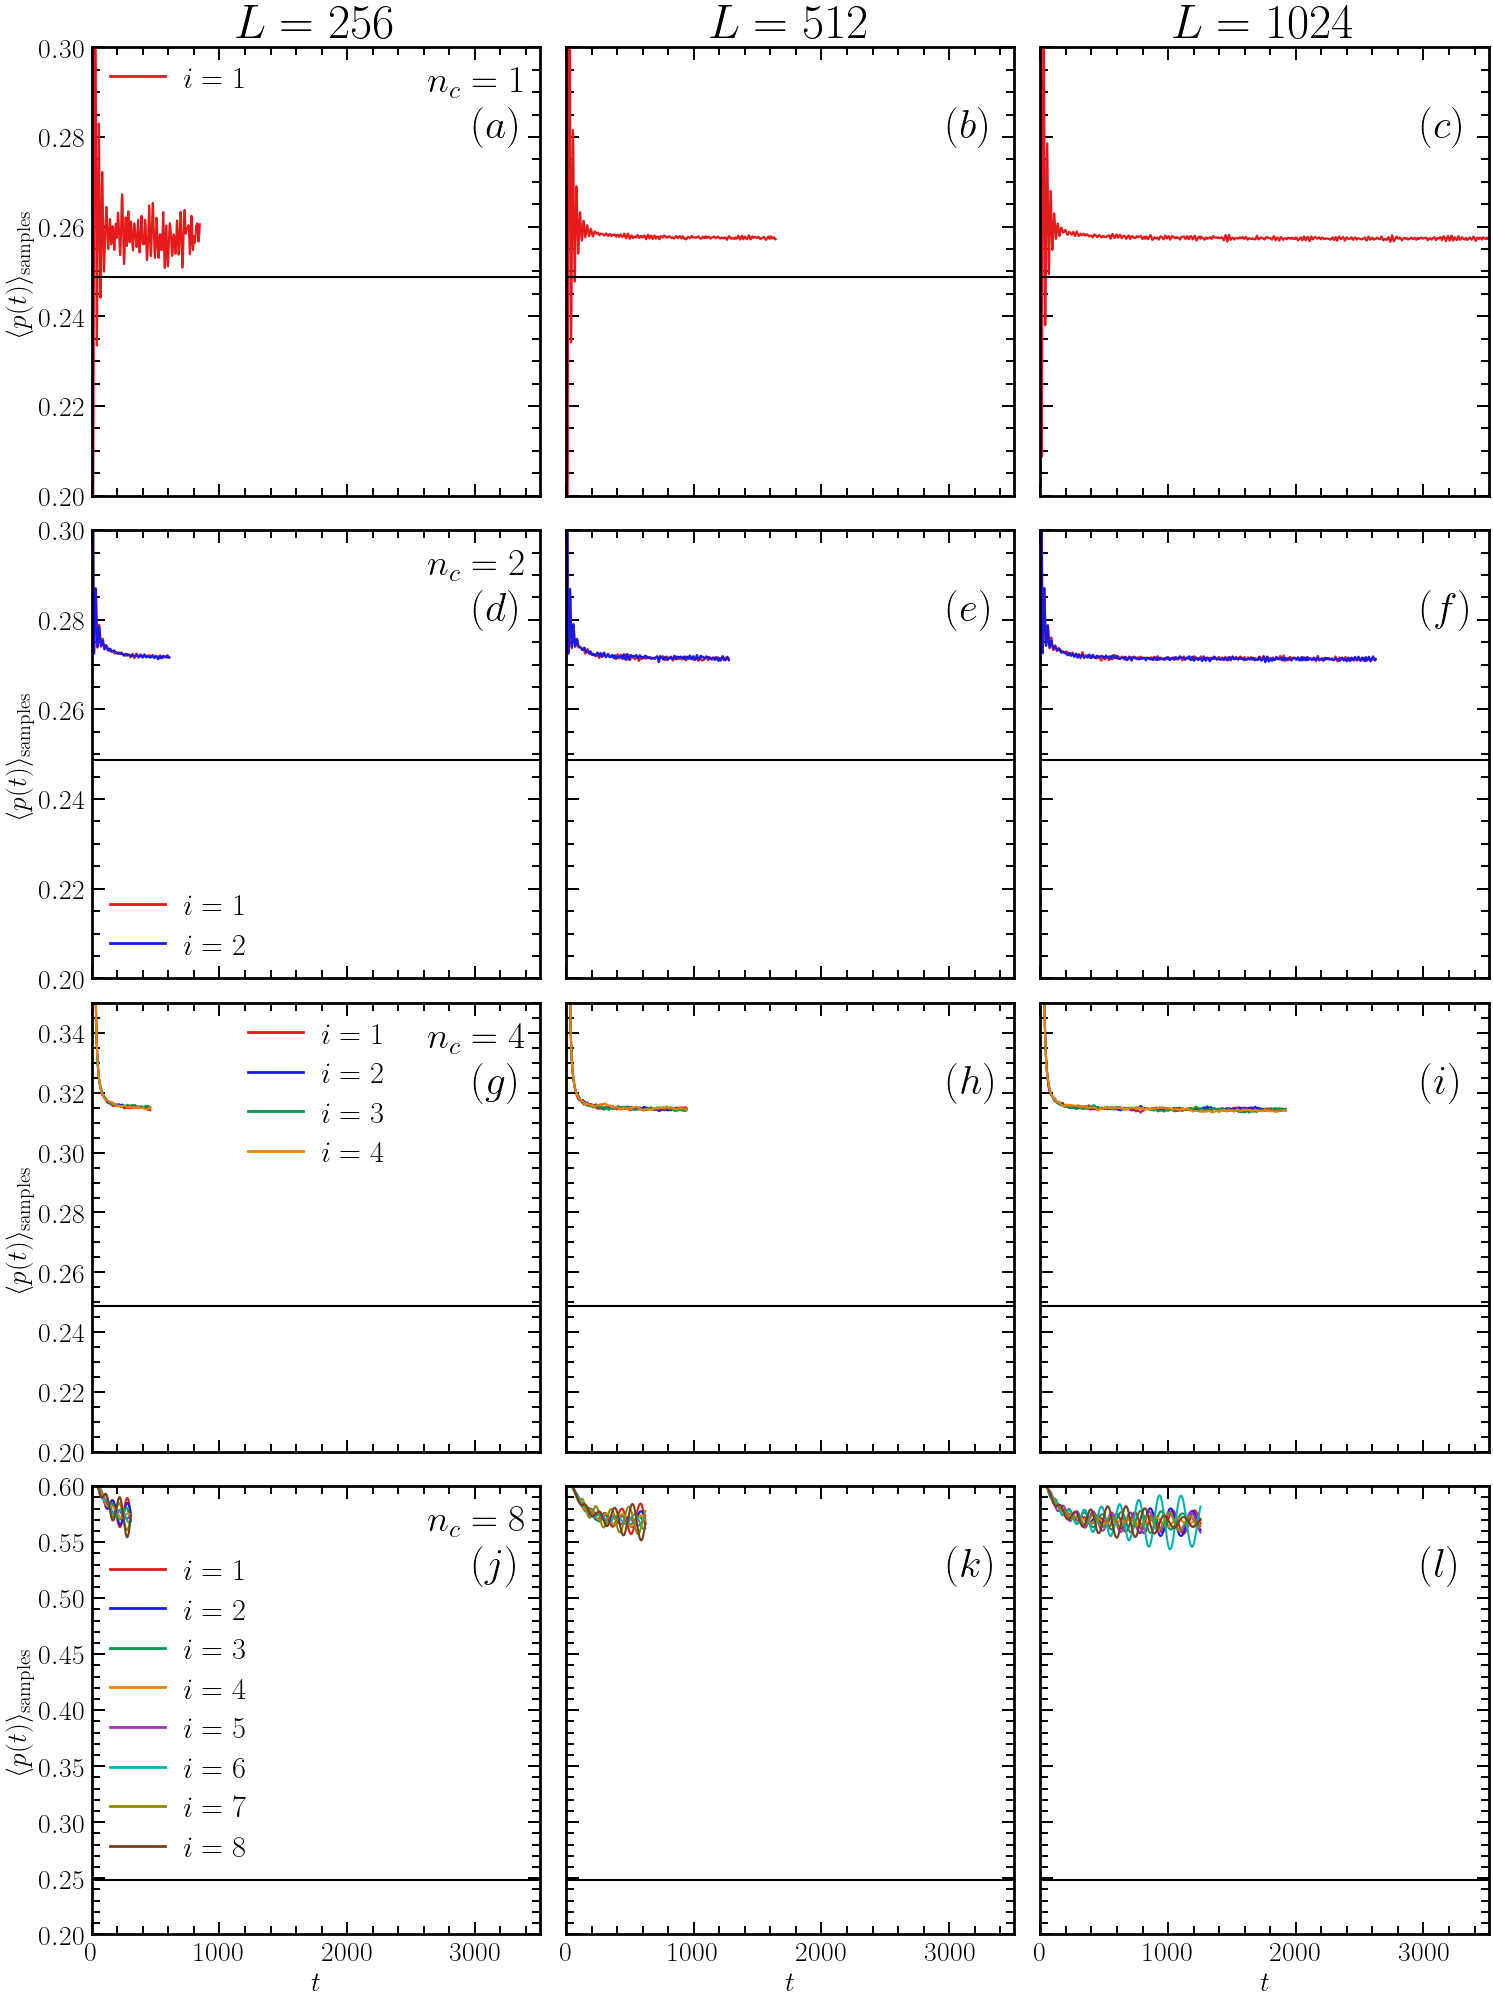

In [133]:
ft = 0.1
c = 0.15
L = [256, 512, 1024]
dim = 3
nc_lst = [1, 2, 4, 8]
p0 = 0.6
P0 = 0.1
base = 5
#p0_values = [0.3, 0.7, 1.0]
fig, axes = plt.subplots(len(nc_lst), 3, figsize=(3*base, 4*base), constrained_layout=True, sharex=True)
pc = 0.24881182
colors = [
    (0.90, 0.10, 0.10),  # red
    (0.10, 0.10, 0.90),  # blue
    (0.00, 0.60, 0.30),  # green
    (0.95, 0.50, 0.00),  # orange
    (0.65, 0.20, 0.75),  # purple
    (0.00, 0.70, 0.70),  # teal
    (0.55, 0.55, 0.00),  # olive
    (0.45, 0.25, 0.10),  # brown
]
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$',
              r'$(d)$', r'$(e)$', r'$(f)$',
              r'$(g)$', r'$(h)$', r'$(i)$',
              r'$(j)$', r'$(k)$', r'$(l)$',]

fs_labels_fig = 30
fs_l_fig = 27

t_max = 0
parms_list = []
for idx_nc, nc in enumerate(nc_lst):
    for index, L in enumerate(L_lst):
        ax = axes[idx_nc, index]
    
        rho = 1/nc            
        path = f"../SOP_data/published/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/fT_constant/fT_{ft:.6e}/c_{c:.6e}/rho_{rho:.4e}"
        
        fn = path + "/properties_mean_bundle.json"
        try:
            bundle = load_properties_bundle(fn)
            data = bundle[p0]["orders"]
            orders = data.keys()
            for idx, ord in enumerate(orders):
                data_keys = data[ord]
                time = data_keys["time"]
                pt_mean = data_keys["pt_mean"]
                t_max = max(t_max, max(time))
                ax.plot(time, pt_mean, ls='solid', color=colors[idx], label=f'$i = {ord + 1}$')
        
        except KeyError:
            print(f"File not found: {fn}")
            parms_list.append((nc, ft, p0, path))
            continue
        except FileNotFoundError:
            print(f"File not found: {fn}")
            parms_list.append((nc, ft, p0, path))
            continue
        
        t_max = max(t_max, max(time))
        ax.set_ylim(0.2, 0.6)
        ax.axhline(pc, color='k', ls='solid')
        #ax.set_ylim(0.245, 0.265)
        ax.set_box_aspect(1)
        
        if(idx_nc == 0):
            ax.set_title(f'$L = {L}$', fontsize=fs_title)
            ax.set_ylim(0.2, 0.30)
            ax.set_ylim(0.2, 0.3)
        if idx_nc==1:
            ax.set_ylim(0.2, 0.3)
        if idx_nc==2:
            ax.set_ylim(0.2, 0.35)
        if idx_nc == 3:
            ax.set_ylim(0.2, 0.6)

        if index==0:
            ax.text(0.75, 0.9, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
            leg = ax.legend(
                fontsize=22,
                handlelength=1.8,
                handletextpad=0.6,
                borderpad=0.4,
                labelspacing=0.4
            )

            for line in leg.get_lines():
                line.set_linewidth(2.0)
            ax.set_ylabel(r'$\langle p(t) \rangle_{\mathrm{samples}}$')
        if idx_nc == len(nc_lst)-1:
            ax.set_xlabel(r'$t$')
        if index != 0:
            ax.tick_params(axis='y', labelleft=False)

for idx, ax in enumerate(axes.flatten()):
    ax.set_xlim(0, t_max)
    ax.text(0.85, 0.80, labels_fig[idx], transform=ax.transAxes , fontsize=fs_labels_fig)

plt.savefig(f"{results}/orders_effects.png", dpi=300)
plt.show()

## Initial Activate Effects

In [ ]:
import json

def load_properties_bundle(fn):
    with open(fn, "r") as f:
        return json.load(f)

def get_group_by_p0_P0(bundle, p0_target, P0_target, tol=1e-12):
    """
    Seleciona o bloco correto dentro de properties_mean_bundle.json
    usando simultaneamente p0_value e P0_value.
    """
    for group in bundle["p0_groups"]:
        p0_value = float(group["p0_value"])
        P0_value = float(group["P0_value"])

        if abs(p0_value - p0_target) < tol and abs(P0_value - P0_target) < tol:
            return group

    raise ValueError(f"Não encontrei grupo com p0={p0_target} e P0={P0_target}")

In [ ]:
ft = 0.1
c = 0.15
L_lst = [256, 512, 1024]
dim = 3
nc_lst = [1, 2, 4, 8]
p0 = 0.6
P0_lst = [0.1, 0.25, 0.50, 1.0]
base = 5
#p0_values = [0.3, 0.7, 1.0]
fig, axes = plt.subplots(len(nc_lst), len(L_lst), figsize=(3*base, 4*base), constrained_layout=True, sharex=True)
pc = 0.24881182
colors = [
    (0.90, 0.10, 0.10),  # red
    (0.10, 0.10, 0.90),  # blue
    (0.00, 0.60, 0.30),  # green
    (0.95, 0.50, 0.00),  # orange
    (0.65, 0.20, 0.75),  # purple
    (0.00, 0.70, 0.70),  # teal
    (0.55, 0.55, 0.00),  # olive
    (0.45, 0.25, 0.10),  # brown
]
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$',
              r'$(d)$', r'$(e)$', r'$(f)$',
              r'$(g)$', r'$(h)$', r'$(i)$',
              r'$(j)$', r'$(k)$', r'$(l)$',]

fs_labels_fig = 30
fs_l_fig = 27

t_max = 0
parms_list = []
for idx_nc, nc in enumerate(nc_lst):
    for index, L in enumerate(L_lst):
        ax = axes[idx_nc, index]
    
        rho = 1/nc            
        path = f"../SOP_data/published/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/fT_constant/fT_{ft:.6e}/c_{c:.6e}/rho_{rho:.4e}"
        
        fn = path + "/properties_mean_bundle.json"
        try:
            bundle = load_properties_bundle(fn)
    
            for P0 in P0_lst:
                group = get_group_by_p0_P0(bundle, p0_target=p0, P0_target=P0)

                data = group["orders"][order_mean]["data"]
                pmean = group["pc_sop"]["mean"]

                t = np.asarray(data["time"])
                pt = np.asarray(data["pt_mean"])
                t_max = max(t_max, max(t))
                ax.plot(t, pt, ls='solid', color=colors[idx], label=f'$i = {ord + 1}$')
        
        except KeyError:
            print(f"File not found: {fn}")
            parms_list.append((nc, ft, p0, path))
            continue
        except FileNotFoundError:
            print(f"File not found: {fn}")
            parms_list.append((nc, ft, p0, path))
            continue
        except Exception as e:
            print(f"Error occurred while processing {fn}: {e}")
            continue

        print(f'Loading data for nc={nc}, ft={ft}')
        
        t_max = max(t_max, max(time))
        ax.set_ylim(0.2, 0.6)
        ax.axhline(pc, color='k', ls='solid')
        #ax.set_ylim(0.245, 0.265)
        ax.set_box_aspect(1)
        
        if(idx_nc == 0):
            ax.text(0.08, 0.9, f'$z = {index+1}L$', transform=ax.transAxes , fontsize=fs_l_fig)
            ax.set_ylim(0.2, 0.30)
            ax.set_ylim(0.2, 0.3)
        if idx_nc==1:
            ax.set_ylim(0.2, 0.3)
        if idx_nc==2:
            ax.set_ylim(0.2, 0.35)
        if idx_nc == 3:
            ax.set_ylim(0.2, 0.6)
        
        if index==2:
            ax.legend()

        if index==0:
            ax.text(0.75, 0.9, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
            ax.legend()
            ax.set_ylabel(r'$\langle p(t) \rangle_{\mathrm{samples}}$')
        if idx_nc == len(nc_lst)-1:
            ax.set_xlabel(r'$t$')
        if index != 0:
            ax.tick_params(axis='y', labelleft=False)

for idx, ax in enumerate(axes.flatten()):
    ax.set_xlim(0, t_max)
    ax.text(0.85, 0.80, labels_fig[idx], transform=ax.transAxes , fontsize=fs_labels_fig)

plt.show()

## $\rho$ ANALYSIS

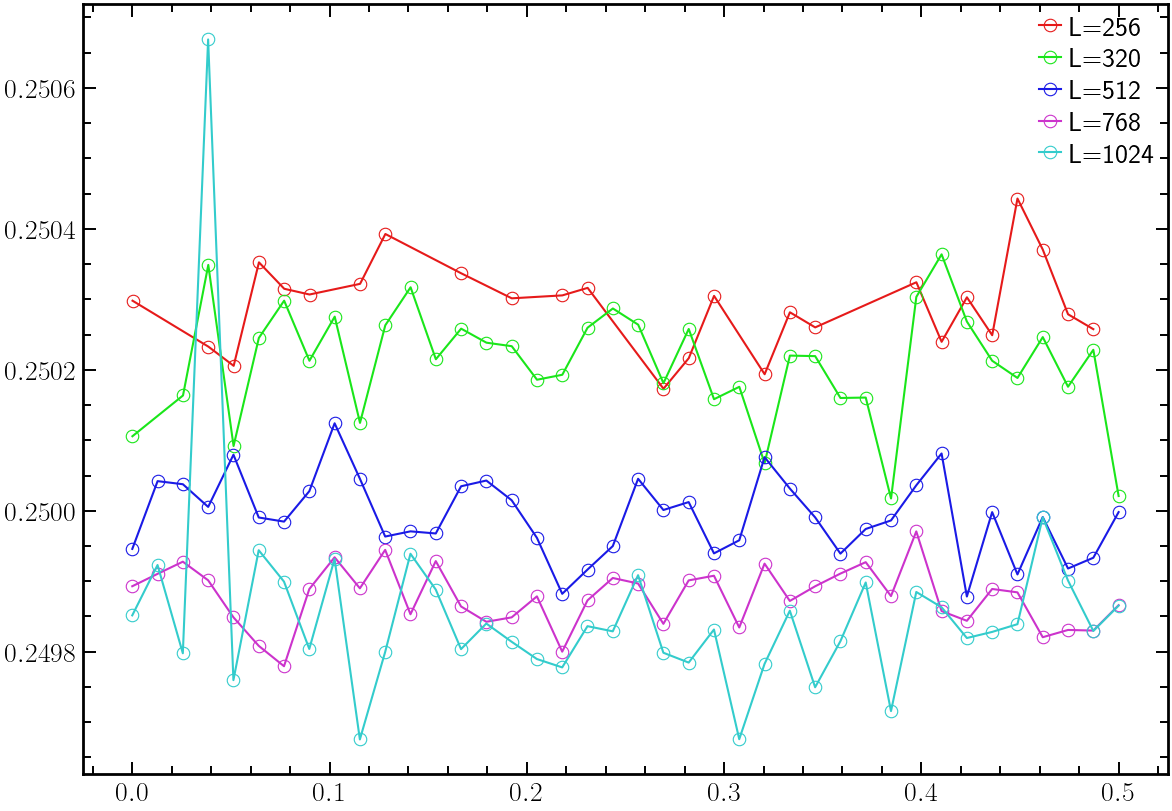

In [7]:
nc = 2
c = 0.05
p0 = 0.6
P0 = 0.1
L_lst = [256, 320, 512, 768, 1024]
df_ft_common = pd.read_csv("../SOP_data/f_T_common.csv")
fT = df_ft_common[(df_ft_common['nc']==nc) & (df_ft_common['c']==c)]['f_T_min_common'].values[0]
fT_lst = df[(df['nc']==nc) & (df['c']==c)  & (df['type_perc']=='bond') & (df['p0']==p0) & (df['P0']==P0) & (df['order']==1)]['f_T'].unique()
        
for L in L_lst:
    df_RHO = df[(df['nc']==nc) & (df['c']==c)  & (df['type_perc']=='bond') & (df['p0']==p0) & (df['P0']==P0) & (df['order']==1) & (df['f_T']==fT)].sort_values('rho')
    DATA = df_RHO[df_RHO['L']==L]
    x = DATA['rho']
    y = DATA['p_mean']
    plt.plot(x, y, marker='o', ls='solid', label=f'L={L}')
plt.legend()
plt.show()

/tmp/ipykernel_3960/347013709.py:33: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0.0, 0.05)


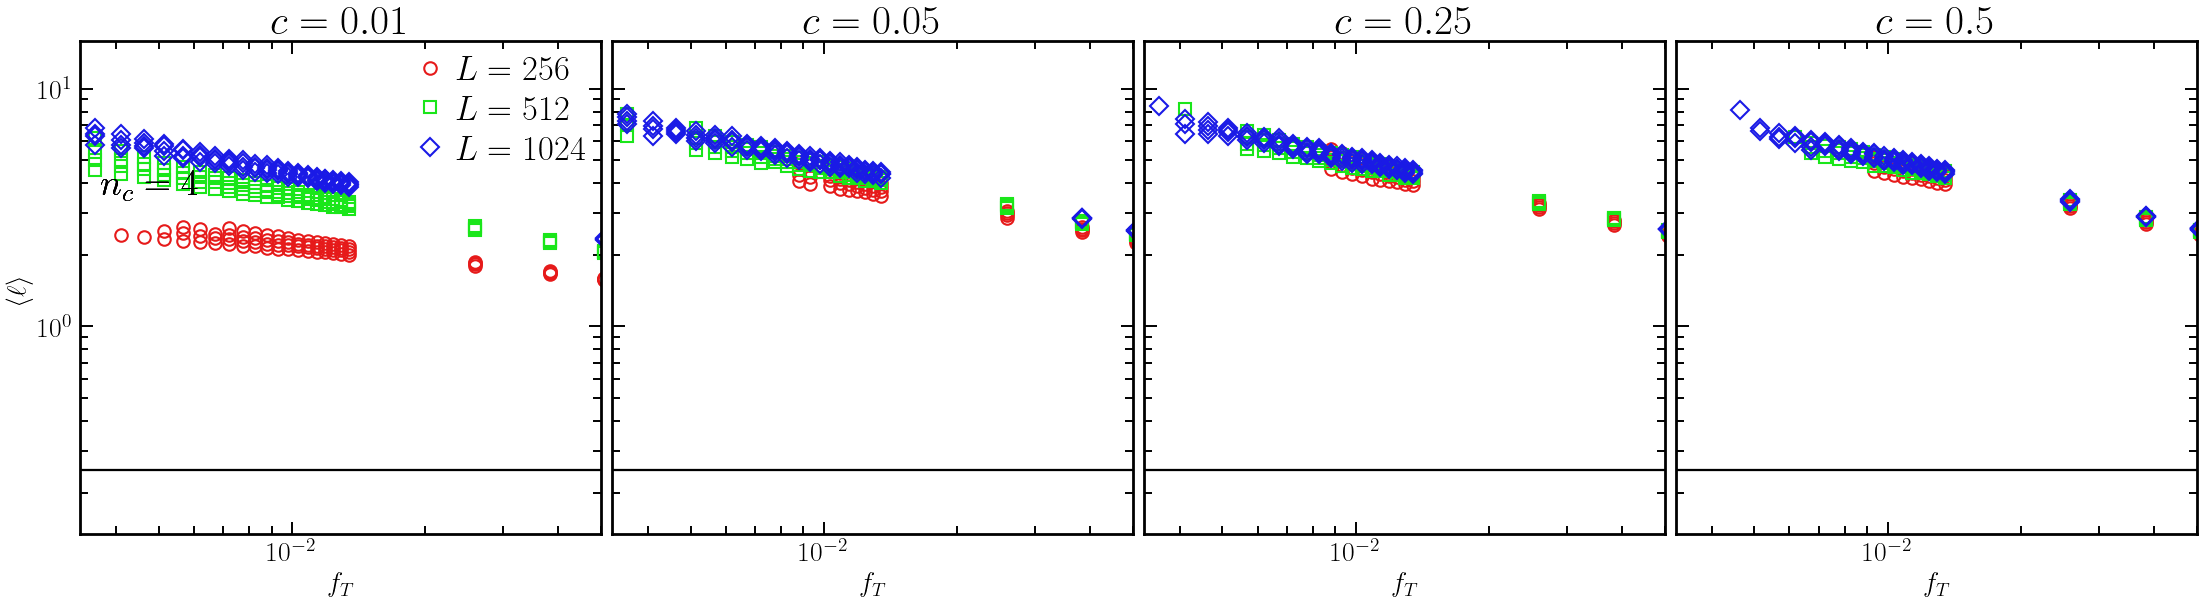

In [15]:
L_lst = [256, 512, 1024]
c_lst = [0.01, 0.05, 0.25, 0.50]
nc = 4
p0 = 0.6
P0 = 0.1

base = 10
#fig, axes = plt.subplots(1, len(c_lst), figsize=(4*base, 1*base), constrained_layout=True, sharey=True)
fig, axes = plt.subplots(1, len(c_lst), figsize=(22, 6), constrained_layout=True, sharey=True, sharex=True)
markers = ['o', 's', 'D']
fs_legend = 25
fs_title = 30
mew = 1.5
pc = 0.24881182
fs_l_fig = 27
for c in c_lst:
    for idx, L in enumerate(L_lst):
        ax = axes[c_lst.index(c)]
        df_b = df[(df['nc']==nc) & (df['L']==L) & (df['c']==c) & (df['type_perc']=='bond') & (df['p0']==p0) & (df['P0']==P0)].sort_values('f_T')
        f_t = df_b['f_T'] 
        pmean = df_b['shortest_path'] / L
        ax.plot(f_t, pmean, marker=markers[idx],mew = mew, ls='None', label=f'$L={L}$' )
        ax.axhline(pc, color='k', ls='solid')
        ax.set_title(f'$c={c}$', fontsize=fs_title)
        
        if(ax==axes[0]):
            ax.set_ylabel(r'$\langle \ell \rangle$')
            ax.legend(fontsize=fs_legend)
            ax.text(0.04, 0.69, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
        ax.set_xlabel(r'$f_T$')
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_xlim(0.0, 0.05)
plt.show()

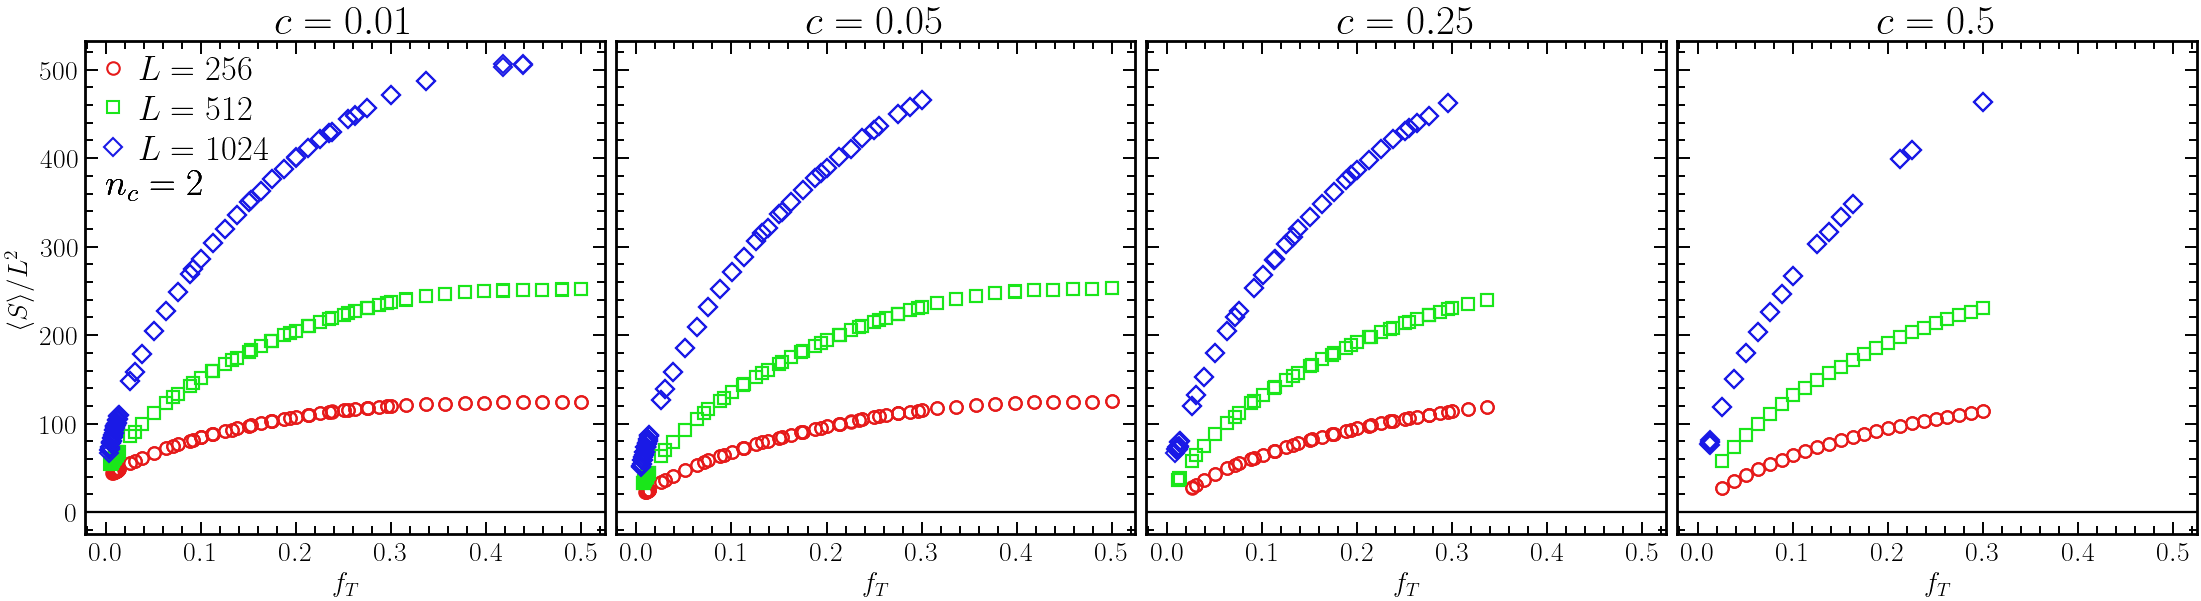

In [16]:
L_lst = [256, 512, 1024]
c_lst = [0.01, 0.05, 0.25, 0.50]
nc = 2
p0 = 0.6
P0 = 0.1

base = 10
#fig, axes = plt.subplots(1, len(c_lst), figsize=(4*base, 1*base), constrained_layout=True, sharey=True)
fig, axes = plt.subplots(1, len(c_lst), figsize=(22, 6), constrained_layout=True, sharey=True, sharex=True)
markers = ['o', 's', 'D']
fs_legend = 25
fs_title = 30
mew = 1.5
pc = 0.24881182
fs_l_fig = 27
for c in c_lst:
    for idx, L in enumerate(L_lst):
        ax = axes[c_lst.index(c)]
        df_b = df[(df['nc']==nc) & (df['L']==L) & (df['c']==c) & (df['type_perc']=='bond') & (df['p0']==p0) & (df['P0']==P0)].sort_values('f_T')
        f_t = df_b['f_T']
        pmean = df_b['S_perc'] / L**2
        ax.plot(f_t, pmean, marker=markers[idx],mew = mew, ls='None', label=f'$L={L}$' )
        ax.axhline(pc, color='k', ls='solid')
        ax.set_title(f'$c={c}$', fontsize=fs_title)
        
        if(ax==axes[0]):
            ax.set_ylabel(r'$\langle S \rangle/L^2$')
            ax.legend(fontsize=fs_legend)
            ax.text(0.04, 0.69, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
        ax.set_xlabel(r'$f_T$')
plt.show()